# 2. NOTEBOOK FINAL DE MODELADO Y ANALISIS ML

- En los notebooks 021 y 022 se han extraido todas las conclusiones y resultados que vamos a exponer en este notebook. El objeto de este es utilizar las minimas celdas posibles, agrupando las de anteriores notebooks, para mostrar el analisis de variables y outliers para el modelado, asi como los propios modelos estudiados y elegidos en cuanto a predicion (ML).

## CODIGO PARA EJECUTAR SI QUIERES CARGAR LOS DATOS **`df_ml`** YA LIMPIOS: 

In [1]:
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import (
    col, unix_timestamp, floor, window,
    hour, dayofweek, dayofmonth, month,
    lag)
import pyspark.sql.functions as F

try:
    spark.stop()
except NameError:
    pass

spark = (
    SparkSession.builder
    .appName("nyc-taxi-ml-pipeline")
    .master("local[*]")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false")
    .getOrCreate()
)

df_ml = spark.read.parquet("../data_ml/df_ml")

print(f"df_ml cargado: {df_ml.count():,} filas")
df_ml.printSchema()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/10 17:06:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


df_ml cargado: 380,354 filas
root
 |-- zone_lon: double (nullable = true)
 |-- zone_lat: double (nullable = true)
 |-- trip_count: long (nullable = true)
 |-- window_start: timestamp (nullable = true)
 |-- hour: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- dayofmonth: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_rush_hour: integer (nullable = true)
 |-- is_late_night: integer (nullable = true)
 |-- lag_1: long (nullable = true)
 |-- lag_2: long (nullable = true)



## CODIGO PARA EJECUTAR SI QUIERES ENTRENAR EL MODELO FINAL Y CARGARLO (SI NO ESTA AUN) EN LA CARPETA **`models`**: 

In [2]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.sql import functions as F
import os

feature_cols = [
    "zone_lon", "zone_lat",
    "hour", "dayofweek",
    "is_weekend", "is_rush_hour", "is_late_night",
    "lag_1", "lag_2"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    maxIter=120,
    maxDepth=5,
    stepSize=0.1
)

pipeline_gbt = Pipeline(stages=[assembler, gbt])

# Dataset completo menos test
train_val_df = (
    df_ml
    .select(*feature_cols, "trip_count", "window_start")
    .dropna()
    .withColumn("label", F.col("trip_count").cast("double"))
    .filter(F.col("window_start") < F.lit("2009-01-27 00:00:00"))
)

model_gbt_final = pipeline_gbt.fit(train_val_df)

# Guardar
os.makedirs("../models", exist_ok=True)
model_gbt_final.write().overwrite().save("../models/gbt_taxi")

print("Modelo entrenado y guardado en: ../models/gbt_taxi")

26/05/10 17:06:16 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


Modelo entrenado y guardado en: ../models/gbt_taxi


## 2.1 LIMPIEZA Y CRECION DE VARIABLES

## Resumen de limpieza de variables y outliers

### 1. Eliminación de registros inválidos

- Se eliminaron viajes con distancia menor o igual a `0.1` millas (185877 registros)
- Se eliminaron viajes con fecha de llegada anterior o igual a fecha de recogida (259749 registros)


```python
Trip_Distance > 0.1
Trip_Dropoff_DateTime > Trip_Pickup_DateTime
```
### 2. Filtrado espacial de coordenadas

- Se filtran los viajes para conservar solo aquellos cuya recogida esta dentro de una caja aproximada de Nueva York

```python
Start_Lon >= -74.3
Start_Lon <= -73.7
Start_Lat >= 40.5
Start_Lat <= 40.9
```

Se observa que 233722 registros estan fuera y que de hecho 205105 tienen coordenadas incorrectas (0,0)

### 3. Creacion de la variable duracion del viaje

- Se crea la variable **Trip_Duration_Minutes** calculada como la diferencia de fecha de llegada - fecha recogida en minutos para poder analizar la duracion real de los viajes y detectar outliers temporales

```python
(unix_timestamp(Trip_Dropoff_DateTime) - unix_timestamp(Trip_Pickup_DateTime)) / 60
```

### 4. Eliminacion de outliers temporales

- Se analizan viajes con duracion muy larga, incluyendo viajes superiores a 2,4,6,8,10,12,24 horas. Finalmente se establece un criterio de eliminar viajes superiores a 180 minutos. Se eliminaron 8600 registros, de los cules casi 6000 eran viajes de mas de 10 horas (suponemos outlier)

```python
Trip_Duration_Minutes <= 180
```

### 5. Variables temporales generadas

A partir de `Trip_Pickup_DateTime` se construye una ventana temporal de 30 minutos y una celda espacial de 0.01 grados (~1 km). Sobre `window_start` (inicio de cada ventana) se derivan las siguientes variables:

**`hour`** — Hora del día (0–23). Captura los patrones dentro de un dia: madrugada sin demanda, picos en hora punta.

**`dayofweek`** — Día de la semana (1=domingo, 7=sábado en Spark). Diferencia comportamiento laboral de fin de semana.

**`dayofmonth`** — Día del mes (1–31). Útil para capturar efectos de principio/fin de mes.

**`month`** — Mes del año (1–12). Recoge estacionalidad anual: menos demanda en invierno, más en verano. (Es util si escalamos a mas meses)

**`is_weekend`** — Binaria (0/1). Vale 1 si `dayofweek >= 6` (sábado o domingo). Resume el cambio de patrón laboral/ocio sin que el modelo tenga que aprenderlo desde `dayofweek`.

**`is_rush_hour`** — Binaria (0/1). Vale 1 si `hour` está en {8, 9, 18, 19, 20}. Señaliza explícitamente los picos de demanda asociados a la entrada y salida del trabajo.

**`is_late_night`** — Binaria (0/1). Vale 1 si `hour` está en {22, 23, 0, 1}. Señaliza explícitamente los picos de demanda asociados a la noches, donde se ve claramente un patrón en los datos. 

**`lag_1`** — Demanda de la misma zona en la ventana inmediatamente anterior (−15 min). Captura inercia a corto plazo.

**`lag_2`** — Demanda de la misma zona hace dos ventanas (−30 min). Complementa `lag_1` para detectar tendencias recientes.


- Aunque `hour`y `dayofweek` contienen implícitamente esta información, se añaden las variables binarias, como señales explícitas que guían al modelo hacia patrones que hemos identificado en el análisis. Modelos como GBT o Random Forest serían capaces de identificarlas pero al ser pocas las variables añadidas no generarían ruido extra del que debamos de preocuparnos. De hecho mejoraremos la eficiencia de entrenamiento. 

### 6. Variables espaciales generadas

- Las coordenadas continuas de recogida se transforman en zonas discretas usando una cuadricula de 0.01 grados (1km aprox)

```python
zone_lon = floor(Start_Lon / 0.01) * 0.01
zone_lat = floor(Start_Lat / 0.01) * 0.01
```

No buscamos trabjar con coordenadas exactas sino con zonas agrupadas de NY.

### 7. Extra


- Agrupamos por ventana de (zone_lon y zon_lat ordenando cronologicamente por window_start)
- Como las primeras ventanas de cada zona no tienen historial suficiente para calcular todos los lags, hacemos un dropna eliminando los retardos incompletos para evitar que el modelo reciba registros NA. 
- Creamos una variable df_ml con los datos generados y creamos una carpeta para poder guardarlos. 



In [3]:
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import (
    col, unix_timestamp, floor, window,
    hour, dayofweek, dayofmonth, month,
    lag
)
import pyspark.sql.functions as F

try:
    spark.stop()
except NameError:
    pass

spark = (
    SparkSession.builder
    .appName("nyc-taxi-ml-pipeline")
    .master("local[*]")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false")
    .getOrCreate()
)

# 1. Carga
df = spark.read.parquet("../data/*.parquet")
distance_col = "Trip_Distance" if "Trip_Distance" in df.columns else "Trip_distance"
n_original = df.count()

# 2. Limpieza
df_clean = (
    df
    .filter(col(distance_col) > 0.1)
    .filter(col("Trip_Dropoff_DateTime") > col("Trip_Pickup_DateTime"))
    .filter(
        (col("Start_Lon") >= -74.3) & (col("Start_Lon") <= -73.7) &
        (col("Start_Lat") >= 40.5)  & (col("Start_Lat") <= 40.9)
    )
    .withColumn(
        "Trip_Duration_Minutes",
        (unix_timestamp("Trip_Dropoff_DateTime") - unix_timestamp("Trip_Pickup_DateTime")) / 60
    )
    .filter(col("Trip_Duration_Minutes") <= 180)
)
n_clean = df_clean.count()

# 3. Grid espacial + features temporales básicas
grid_size   = 0.01
window_size = "15 minutes"

df_features = (
    df_clean
    .withColumn("zone_lon", floor(col("Start_Lon") / grid_size) * grid_size)
    .withColumn("zone_lat", floor(col("Start_Lat") / grid_size) * grid_size)
)

# 4. Agregación por zona y ventana temporal --> target trip_count
df_agg = (
    df_features
    .groupBy(
        window(col("Trip_Pickup_DateTime"), window_size),
        "zone_lon",
        "zone_lat"
    )
    .count()
    .withColumnRenamed("count", "trip_count")
    .withColumn("window_start", col("window.start"))
    .drop("window")
)

# 5. Features temporales derivadas de window_start
df_agg = (
    df_agg
    .withColumn("hour",        hour("window_start"))
    .withColumn("dayofweek",   dayofweek("window_start"))
    .withColumn("dayofmonth",  dayofmonth("window_start"))
    .withColumn("month",       month("window_start"))
    .withColumn("is_weekend",  (F.col("dayofweek") >= 6).cast("int"))
    .withColumn("is_rush_hour", F.col("hour").isin([8, 9, 18, 19, 20]).cast("int"))
    .withColumn("is_late_night", F.col("hour").isin([22,23,0,1]).cast("int")))


# 6. Lag features por zona ordenadas por tiempo
w_zone = Window.partitionBy("zone_lon", "zone_lat").orderBy("window_start")

df_ml = (
    df_agg
    .withColumn("lag_1",  F.lag("trip_count", 1).over(w_zone))
    .withColumn("lag_2",  F.lag("trip_count", 2).over(w_zone))
    .dropna(subset=["lag_1", "lag_2"])
)

# Resumen
print(f"Registros originales:        {n_original:,}")
print(f"Registros tras limpieza:     {n_clean:,}")
print(f"Registros eliminados:        {n_original - n_clean:,}")
print(f"Dataset ML final:            {df_ml.count():,} filas")
df_ml.printSchema()
df_ml.show(5, truncate=False)

Registros originales:        14,092,413
Registros tras limpieza:     13,447,101
Registros eliminados:        645,312


Dataset ML final:            380,354 filas
root
 |-- zone_lon: double (nullable = true)
 |-- zone_lat: double (nullable = true)
 |-- trip_count: long (nullable = false)
 |-- window_start: timestamp (nullable = true)
 |-- hour: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- dayofmonth: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_rush_hour: integer (nullable = true)
 |-- is_late_night: integer (nullable = true)
 |-- lag_1: long (nullable = true)
 |-- lag_2: long (nullable = true)



+--------+--------+----------+-------------------+----+---------+----------+-----+----------+------------+-------------+-----+-----+
|zone_lon|zone_lat|trip_count|window_start       |hour|dayofweek|dayofmonth|month|is_weekend|is_rush_hour|is_late_night|lag_1|lag_2|
+--------+--------+----------+-------------------+----+---------+----------+-----+----------+------------+-------------+-----+-----+
|-74.3   |40.69   |1         |2009-01-06 17:45:00|17  |3        |6         |1    |0         |0           |0            |1    |2    |
|-74.3   |40.69   |1         |2009-01-11 16:45:00|16  |1        |11        |1    |0         |0           |0            |1    |1    |
|-74.27  |40.76   |1         |2009-01-02 16:30:00|16  |6        |2         |1    |1         |0           |0            |1    |1    |
|-74.27  |40.76   |1         |2009-01-02 18:15:00|18  |6        |2         |1    |1         |1           |0            |1    |1    |
|-74.27  |40.76   |1         |2009-01-02 18:45:00|18  |6        |2   

## GENERO EL PARQUET EN data_ml\ NO EJECUTAR DE NUEVO SALVO CAMBIOS EN **`df_ml`** 

In [4]:
import os

processed_dir = "../data_ml"
df_ml_path = os.path.join(processed_dir, "df_ml")

os.makedirs(processed_dir, exist_ok=True)

(
    df_ml
    .repartition(8)
    .write
    .mode("overwrite")
    .parquet(df_ml_path)
)

print(f"df_ml guardado en: {df_ml_path}")
print(f"Filas guardadas: {df_ml.count():,}")

df_ml guardado en: ../data_ml/df_ml


Filas guardadas: 380,354


## 2.2 MODELOS ML

### 1. Preparacion del dataset para ML

- A partir de `df_ml` se construye `df_model`, el dataset comun a todos lo modelos, seleccionando las features definitivas y el target. La columna `trip_count` se pasa a double y se renomvra como `label` 
- Excluimos de momento `month` y `dayofmonth` al estar probando solo con enero, genera varianza cero y podria encontrar patrones que no son reales, se descomentaran al probar con mas meses. 
- La division es temporal, no aleatoria para respetar la causalidad de los datos, al final tenemos una serie temporal

- **Train**; primeras 3 semanas , 1-22 enero --> Base de entrenamiento de todos los modelos
- **Validacion**; 22 al 27 de enero --> Se usa para comparar modelos y ajustar hiperparametros
- **Test**; del 27 al 31 de enero --> Reservado para el modelo final
- **Train + Validacion**; Union de los dos primeros --> Para reentrenar modelo final antes de test

Cacheamos los tres datasets principales en memoria ya que se reutilizaron varias veces.

### 2. Exploracion de modelos e hiperparametros

En esta parte del trabajo realizamos una comparación de modelos supervisados usando validación cruzada, con el objetivo de encontrar combinaciones de hiperparámetros que mejorasen el rendimiento del modelo sin caer en sobreajuste.

### 1. Decision Tree con Cross Validation

Primero entrenamos un modelo de **Decision Tree** aplicando **Cross Validation** para probar distintas configuraciones del árbol.

Los hiperparámetros evaluados fueron:

- `maxDepth`: `12`, `14`, `16`, `18`
- `minInstancesPerNode`: `1`, `2`, `5`

`maxDepth` controla la profundidad máxima del árbol. Cuanto mayor es este valor, más complejo puede ser el modelo, ya que puede crear más divisiones. Sin embargo, una profundidad demasiado alta puede provocar sobreajuste.

`minInstancesPerNode` indica el número mínimo de instancias que debe tener cada nodo. Valores más altos hacen que el árbol sea más conservador, ya que evita crear divisiones con muy pocos datos.

El objetivo de esta prueba fue encontrar un equilibrio entre árboles suficientemente expresivos y modelos que generalicen bien sobre datos no vistos.

### 2. Random Forest

Después entrenamos un modelo de **Random Forest**, que combina varios árboles de decisión para mejorar la estabilidad y reducir el riesgo de sobreajuste.

Los hiperparámetros evaluados fueron:

- `numTrees`: `30`, `60`
- `maxDepth`: `6`, `8`, `12`

`numTrees` define el número de árboles que forman el bosque. Al aumentar este valor, el modelo suele ser más robusto, aunque también aumenta el coste computacional.

`maxDepth` limita la profundidad de cada árbol individual. En Random Forest no siempre es necesario usar árboles muy profundos, porque el modelo ya gana capacidad predictiva combinando muchos árboles.

Con este modelo buscamos comprobar si un enfoque basado en múltiples árboles ofrecía mejor rendimiento que un único Decision Tree.

### 3. Gradient-Boosted Trees

Finalmente entrenamos un modelo de **Gradient-Boosted Trees**, que construye árboles de forma secuencial, donde cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

Los hiperparámetros evaluados fueron:

- `maxIter`: `60`, `120`
- `maxDepth`: `4`, `5`
- `stepSize`: `0.05`, `0.1`

`maxIter` indica el número de árboles o iteraciones del boosting. Un valor mayor permite al modelo aprender patrones más complejos, aunque también puede aumentar el riesgo de sobreajuste.

`maxDepth` controla la profundidad de cada árbol débil. En GBT se suelen utilizar árboles menos profundos que en Random Forest, porque el aprendizaje se realiza de manera acumulativa.

`stepSize`, también llamado learning rate, controla cuánto aporta cada árbol nuevo al modelo final. Un valor más bajo, como `0.05`, hace que el aprendizaje sea más lento pero potencialmente más estable. Un valor más alto, como `0.1`, permite aprender más rápido, aunque puede ser menos fino.

## Resumen

En conjunto, probamos tres enfoques:

- **Decision Tree**, como modelo base interpretable.
- **Random Forest**, para mejorar la estabilidad usando múltiples árboles independientes.
- **Gradient-Boosted Trees**, para construir un modelo más potente mediante aprendizaje secuencial.

La validación cruzada permitió comparar distintas combinaciones de hiperparámetros de forma más fiable, evaluando el rendimiento medio del modelo sobre diferentes particiones del conjunto de entrenamiento.



In [4]:
from pyspark.sql import functions as F

feature_cols = [
    "zone_lon",
    "zone_lat",
    "hour",
    "dayofweek",
    #"dayofmonth",
    #"month",
    "is_weekend",
    "is_rush_hour",
    "is_late_night",
    "lag_1",
    "lag_2",
]

label_col = "label"

# Dataset comun para todos los modelos.
df_model = (
    df_ml
    .select(*feature_cols, "trip_count", "window_start")
    .dropna()
    .withColumn(label_col, F.col("trip_count").cast("double"))
)

# Train: primeras 3 semanas de enero.
train_df = df_model.filter(F.col("window_start") < F.lit("2009-01-22 00:00:00"))

# Validation: dias intermedios para elegir hiperparametros y comparar modelos.
val_df = df_model.filter(
    (F.col("window_start") >= F.lit("2009-01-22 00:00:00")) &
    (F.col("window_start") < F.lit("2009-01-27 00:00:00"))
)

# Test: ultima parte del mes; no se usa hasta haber elegido el modelo final.
test_df = df_model.filter(F.col("window_start") >= F.lit("2009-01-27 00:00:00"))

# Train + validation para reentrenar el mejor modelo final.
train_val_df = train_df.unionByName(val_df)

train_df.cache()
train_df.count()
val_df.cache()
val_df.count()
train_val_df.cache()
train_val_df.count()

print(f"Filas totales para ML: {df_model.count():,}")
print(f"Train:       {train_df.count():,}")
print(f"Validation:  {val_df.count():,}")
print(f"Train + val: {train_val_df.count():,}")
print(f"Test:        {test_df.count():,}")

df_model.select("window_start", *feature_cols, "trip_count").show(10, truncate=False)

Filas totales para ML: 380,354
Train:       254,860
Validation:  63,344
Train + val: 318,204
Test:        62,150
+-------------------+--------+------------------+----+---------+----------+------------+-------------+-----+-----+----------+
|window_start       |zone_lon|zone_lat          |hour|dayofweek|is_weekend|is_rush_hour|is_late_night|lag_1|lag_2|trip_count|
+-------------------+--------+------------------+----+---------+----------+------------+-------------+-----+-----+----------+
|2009-01-22 23:45:00|-73.93  |40.85             |23  |5        |0         |0           |1            |1    |1    |1         |
|2009-01-18 17:15:00|-73.97  |40.800000000000004|17  |1        |0         |0           |0            |40   |42   |39        |
|2009-01-25 08:00:00|-73.98  |40.74             |8   |1        |0         |1           |0            |48   |46   |45        |
|2009-01-03 14:45:00|-73.93  |40.75             |14  |7        |1         |0           |0            |1    |2    |2         |
|2009

In [9]:
# ============================================================
# DECISION TREE — maxDepth=14, minInstancesPerNode=5
# ============================================================
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="label",
    maxDepth=14,
    minInstancesPerNode=5
)
pipeline_dt = Pipeline(stages=[assembler, dt])
model_dt    = pipeline_dt.fit(train_df)

preds_dt_train = model_dt.transform(train_df)
preds_dt_val   = model_dt.transform(val_df)

print("[DT] Train  — RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(
    evaluator_rmse.evaluate(preds_dt_train),
    evaluator_mae.evaluate(preds_dt_train),
    evaluator_r2.evaluate(preds_dt_train)
))
print("[DT] Val    — RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(
    evaluator_rmse.evaluate(preds_dt_val),
    evaluator_mae.evaluate(preds_dt_val),
    evaluator_r2.evaluate(preds_dt_val)
))


26/05/06 12:40:57 WARN DAGScheduler: Broadcasting large task binary with size 1025.2 KiB


[DT] Train  — RMSE: 19.2268 | MAE: 7.6869 | R2: 0.9809


[DT] Val    — RMSE: 24.3111 | MAE: 8.9955 | R2: 0.9725


In [ ]:
# ============================================================
# RANDOM FOREST — numTrees=60, maxDepth=12
# ============================================================
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=60,
    maxDepth=12
)
pipeline_rf = Pipeline(stages=[assembler, rf])
model_rf    = pipeline_rf.fit(train_df)

preds_rf_train = model_rf.transform(train_df)
preds_rf_val   = model_rf.transform(val_df)

print("[RF] Train  — RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(
    evaluator_rmse.evaluate(preds_rf_train),
    evaluator_mae.evaluate(preds_rf_train),
    evaluator_r2.evaluate(preds_rf_train)
))
print("[RF] Val    — RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(
    evaluator_rmse.evaluate(preds_rf_val),
    evaluator_mae.evaluate(preds_rf_val),
    evaluator_r2.evaluate(preds_rf_val)
))


26/05/06 12:47:16 WARN DAGScheduler: Broadcasting large task binary with size 6.1 MiB
26/05/06 12:48:08 WARN DAGScheduler: Broadcasting large task binary with size 1313.1 KiB
26/05/06 12:48:14 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/05/06 12:48:24 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB
26/05/06 12:48:38 WARN DAGScheduler: Broadcasting large task binary with size 1351.5 KiB
26/05/06 12:48:45 WARN DAGScheduler: Broadcasting large task binary with size 8.6 MiB
26/05/06 12:49:11 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/05/06 12:49:23 WARN DAGScheduler: Broadcasting large task binary with size 15.3 MiB
26/05/06 12:50:07 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
26/05/06 12:50:28 WARN DAGScheduler: Broadcasting large task binary with size 26.1 MiB
26/05/06 12:51:41 WARN DAGScheduler: Broadcasting large task binary with size 6.1 MiB


[DT] Train  — RMSE: 20.6162 | MAE: 8.0852 | R2: 0.9780


[DT] Val    — RMSE: 23.9072 | MAE: 8.7072 | R2: 0.9734


In [12]:
# ============================================================
# GBT — maxIter=120, maxDepth=5, stepSize=0.1
# ============================================================

from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
featuresCol="features",
labelCol="label",
maxIter=120,
maxDepth=5,
stepSize=0.1)

pipeline_gbt = Pipeline(stages=[assembler, gbt])
model_gbt = pipeline_gbt.fit(train_df)
preds_gbt_train = model_gbt.transform(train_df)
preds_gbt_val = model_gbt.transform(val_df)

print("[GBT] Train — RMSE: {:.4f} | MAE: {:.4f}  | R2: {:.4f}".format(
evaluator_rmse.evaluate(preds_gbt_train),
evaluator_mae.evaluate(preds_gbt_train),
evaluator_r2.evaluate(preds_gbt_train)
))

print("[GBT] Val — RMSE: {:.4f} | MAE: {:.4f}  | R2: {:.4f}".format(
evaluator_rmse.evaluate(preds_gbt_val),
evaluator_mae.evaluate(preds_gbt_val),
evaluator_r2.evaluate(preds_gbt_val)
))



26/05/06 13:03:52 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/06 13:03:52 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


[GBT] Train — RMSE: 19.2318 | MAE: 8.2767  | R2: 0.9809


[GBT] Val — RMSE: 20.9983 | MAE: 8.4098  | R2: 0.9795


## Comparativa de modelos

| Modelo | Hiperparámetros | Split | RMSE | MAE | R2 |
|---|---|---|---:|---:|---:|
| Decision Tree | `maxDepth=14`, `minInstancesPerNode=5` | Train | 19.2268 | 7.6869 | 0.9809 |
| Decision Tree | `maxDepth=14`, `minInstancesPerNode=5` | Validation | 24.3111 | 8.9955 | 0.9725 |
| Random Forest | `numTrees=60`, `maxDepth=12` | Train | 20.6162 | 8.0852 | 0.9780 |
| Random Forest | `numTrees=60`, `maxDepth=12` | Validation | 23.9072 | 8.7072 | 0.9734 |
| GBT | `maxIter=120`, `maxDepth=5`, `stepSize=0.1` | Train | 19.2318 | 8.2767 | 0.9809 |
| GBT | `maxIter=120`, `maxDepth=5`, `stepSize=0.1` | Validation | 20.9983 | 8.4098 | 0.9795 |

## Ranking en validation

| Ranking | Modelo | RMSE | MAE | R2 |
|---:|---|---:|---:|---:|
| 1 | GBT | 20.9983 | 8.4098 | 0.9795 |
| 2 | Random Forest | 23.9072 | 8.7072 | 0.9734 |
| 3 | Decision Tree | 24.3111 | 8.9955 | 0.9725 |

## Conclusión

El mejor modelo en el conjunto de validación fue **GBT**, ya que obtuvo el menor `RMSE`, el menor `MAE` y el mayor `R2`.

Esto indica que el modelo de **Gradient-Boosted Trees** fue el que mejor generalizó sobre datos no vistos dentro del bloque temporal de validación.


In [6]:
# ============================================================
# GBT FINAL — reentrenado en train+val, evaluado en test --> ejecutar modelo anterior para esta celda
# ============================================================
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

model_gbt_final = pipeline_gbt.fit(train_val_df)

preds_gbt_test = model_gbt_final.transform(test_df)

print("[GBT FINAL] Test — RMSE: {:.4f} | MAE: {:.4f} | R2: {:.4f}".format(
    evaluator_rmse.evaluate(preds_gbt_test),
    evaluator_mae.evaluate(preds_gbt_test),
    evaluator_r2.evaluate(preds_gbt_test)
))

26/05/07 16:04:41 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/07 16:04:41 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


[GBT FINAL] Test — RMSE: 12.8177 | MAE: 5.4582 | R2: 0.9752


[2.07034385e-02 2.20028103e-02 3.08770537e-02 1.43499616e-02
 4.31034215e-04 2.40917884e-03 3.18489222e-03 8.80909386e-01
 2.51322442e-02]


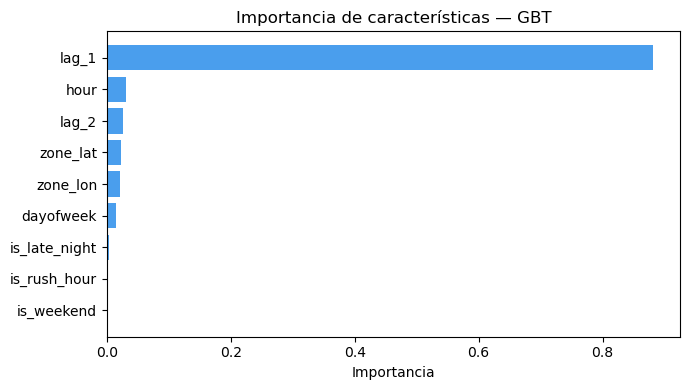

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.ml import PipelineModel

feature_names = ["zone_lon", "zone_lat", "hour", "dayofweek",
                 "is_weekend", "is_rush_hour", "is_late_night",
                 "lag_1", "lag_2"]

pipeline_model = PipelineModel.load("../models/gbt_taxi")                
gbt_model = pipeline_model.stages[-1]

importances = gbt_model.featureImportances.toArray()
print(importances)

df_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
df_imp = df_imp.sort_values("importance", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(df_imp["feature"], df_imp["importance"], color="#4a9eed")
plt.xlabel("Importancia")
plt.title("Importancia de características — GBT")
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=150)